# Polymarket Simple Tutorial

This notebook is a simple research starter for Polymarket-style algorithmic trading workflows. It uses three API groups:

- **Gamma API**: find markets and token IDs
- **CLOB API**: get prices, order books, and price history
- **Data API**: get trades, holders, and user positions

The goal is to move from market discovery to token-level microstructure analysis in one place.


## What This Notebook Does

This notebook walks through a very simple Polymarket research workflow from discovery to market microstructure.

We use three API groups:

- **Gamma API** to discover markets and extract token IDs
- **CLOB API** to inspect the live order book, best prices, and recent price history
- **Data API** to look at recent trades, top holders, and user positions

A useful mental model is: **find market -> resolve token ID -> inspect liquidity -> inspect activity**.


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)


In [2]:
GAMMA_BASE = 'https://gamma-api.polymarket.com'
CLOB_BASE = 'https://clob.polymarket.com'
DATA_BASE = 'https://data-api.polymarket.com'

DEFAULT_HEADERS = {
    'Accept': 'application/json',
    'User-Agent': 'research-notebook/1.0'
}

SEARCH_TEXT = 'fed'
USER_ADDRESS = '0x0000000000000000000000000000000000000000'  # replace with a real wallet


In [3]:
def get_json(url, params=None):
    response = requests.get(url, params=params, headers=DEFAULT_HEADERS, timeout=30)
    response.raise_for_status()
    return response.json()

def force_list(x):
    if x is None:
        return []
    return x if isinstance(x, list) else [x]

def extract_token_ids(market):
    token_ids = []

    for token in force_list(market.get('tokens')):
        for key in ('token_id', 'tokenId', 'id', 'asset_id', 'assetId'):
            if token.get(key) is not None:
                token_ids.append(str(token[key]))
                break

    for key in ('clobTokenIds', 'tokenIds'):
        raw = market.get(key)
        if isinstance(raw, str):
            parsed = None
            try:
                parsed = json.loads(raw)
            except Exception:
                parsed = None

            if isinstance(parsed, list):
                token_ids.extend([str(x) for x in parsed])
            else:
                for part in raw.split(','):
                    part = part.strip().strip('[]" ')
                    if part:
                        token_ids.append(part)
        elif isinstance(raw, list):
            token_ids.extend([str(x) for x in raw])

    seen = set()
    clean = []
    for token_id in token_ids:
        if token_id not in seen:
            seen.add(token_id)
            clean.append(token_id)
    return clean


## 1. Gamma API: Find Markets and Token IDs

Polymarket markets are easier to discover at the market or event level first.

In practice, the Gamma API is the discovery layer. It helps answer questions like:

- What markets match a search term?
- Which markets are active right now?
- What token IDs belong to that market?

The token ID is the bridge into the trading APIs, because the order book and pricing endpoints operate at the token level.


In [4]:
gamma_markets = get_json(
    f'{GAMMA_BASE}/markets',
    params={
        'search': SEARCH_TEXT,
        'limit': 10,
        'active': 'true',
        'closed': 'false',
    },
)

gamma_df = pd.DataFrame(gamma_markets)
if not gamma_df.empty:
    cols = [c for c in ['question', 'slug', 'volume', 'liquidity', 'endDate', 'clobTokenIds'] if c in gamma_df.columns]
    display(gamma_df[cols].head())
else:
    print('No markets returned from Gamma API.')


question,slug,volume,liquidity,endDate,clobTokenIds
New Rihanna Album before GTA VI?,new-rhianna-album-before-gta-vi-926,829264.6039810063,14210.2879,2026-07-31T12:00:00Z,"[""98022490269692409998126496127597032490334070080325855126491859374983463996227"", ""53831553061883006530739877284105938919721408776239639687877978808906551086026""]"
New Playboi Carti Album before GTA VI?,new-playboi-carti-album-before-gta-vi-421,740869.9925149459,12179.8557,2026-07-31T12:00:00Z,"[""88275040060084773376557187972215267513049848642895776801789297917961077894224"", ""94376205816022955542979635542279932967359915765455578534002478996104754801969""]"
Will Jesus Christ return before GTA VI?,will-jesus-christ-return-before-gta-vi-665,11597630.205407742,383446.7044,2026-07-31T12:00:00Z,"[""90435811253665578014957380826505992530054077692143838383981805324273750424057"", ""92388629082681805622801622703528982922543286352927708208755887536971583436902""]"
Trump out as President before GTA VI?,trump-out-as-president-before-gta-vi-846,669744.0799680072,30355.6265,2026-07-31T12:00:00Z,"[""108999723207897941876452935557011604067917389120996960199512481363958770540884"", ""64533579809297525579033609963634939501013332859992608996100633472507000251907""]"
Will China invades Taiwan before GTA VI?,will-china-invades-taiwan-before-gta-vi-716-644,1869539.511795066,39825.8786,2026-07-31T12:00:00Z,"[""21695138873211375451055566770107682325494206727818897067665810321709249824909"", ""17516427576383382756368467656206258206490015951115433065318503962238754362428""]"


In [5]:
filtered_markets = [
    market for market in gamma_markets
    if SEARCH_TEXT.lower() in str(market.get('question', '')).lower()
    or SEARCH_TEXT.lower() in str(market.get('slug', '')).lower()
]

selected_market = filtered_markets[0] if filtered_markets else (gamma_markets[0] if gamma_markets else {})
selected_tokens = extract_token_ids(selected_market)

print('Selected market:')
print(selected_market.get('question', selected_market.get('slug', 'N/A')))
print('Token IDs:')
print(selected_tokens)


Selected market:
New Rihanna Album before GTA VI?
Token IDs:
['98022490269692409998126496127597032490334070080325855126491859374983463996227', '53831553061883006530739877284105938919721408776239639687877978808906551086026']


## 2. CLOB API: Prices, Order Books, and Price History

After we have a token ID, we can query the central limit order book.

This is the part of the workflow that is most useful for algorithmic trading research, because it shows:

- the best bid and best ask
- the depth resting on each side of the book
- the recent path of traded or quoted prices

This is where you can begin thinking about spread, liquidity, slippage, and short-term price behavior.


In [6]:
def get_order_book(token_id):
    return get_json(f'{CLOB_BASE}/book', params={'token_id': token_id})

def get_market_price(token_id, side='BUY'):
    return get_json(f'{CLOB_BASE}/price', params={'token_id': token_id, 'side': side})

def get_prices_history(token_id, interval='1d', fidelity=60):
    return get_json(
        f'{CLOB_BASE}/prices-history',
        params={'market': token_id, 'interval': interval, 'fidelity': fidelity},
    )


In [7]:
token_id = selected_tokens[0] if selected_tokens else None

if token_id is None:
    print('No token ID found from the selected market.')
else:
    order_book = get_order_book(token_id)
    buy_price = get_market_price(token_id, side='BUY')
    sell_price = get_market_price(token_id, side='SELL')
    price_history = get_prices_history(token_id, interval='1d', fidelity=60)

    print('Best buy price response:')
    print(buy_price)
    print('\nBest sell price response:')
    print(sell_price)

    bids = pd.DataFrame(order_book.get('bids', []))
    asks = pd.DataFrame(order_book.get('asks', []))

    print('\nTop bids:')
    display(bids.head())
    print('Top asks:')
    display(asks.head())


Best buy price response:
{'price': '0.51'}

Best sell price response:
{'price': '0.52'}

Top bids:


price,size
0.01,29231.36
0.02,7907.23
0.03,811.17
0.05,3700
0.07,1028.57


Top asks:


price,size
0.99,335.5
0.98,4641.48
0.97,1893.52
0.96,2005
0.93,3564.71


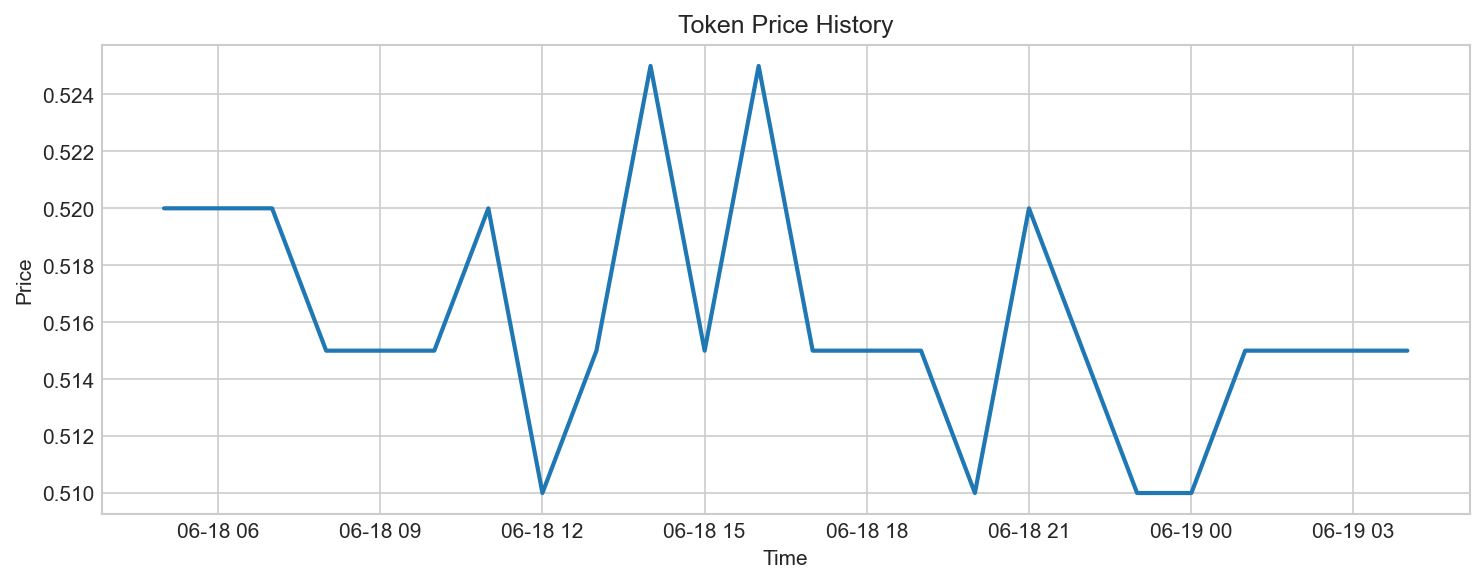

In [8]:
if token_id is not None:
    history_points = price_history.get('history', price_history.get('data', []))
    history_df = pd.DataFrame(history_points)

    if not history_df.empty and {'t', 'p'}.issubset(history_df.columns):
        history_df['timestamp'] = pd.to_datetime(history_df['t'], unit='s', errors='coerce')
        history_df['p'] = pd.to_numeric(history_df['p'], errors='coerce')

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(history_df['timestamp'], history_df['p'], color='#1f77b4', linewidth=2)
        ax.set_title('Token Price History')
        ax.set_ylabel('Price')
        ax.set_xlabel('Time')
        plt.tight_layout()
        plt.show()
    else:
        print('Price history response did not include a standard history payload.')
        print(price_history)


## 3. Data API: Trades, Holders, and User Positions

The Data API adds market-activity context around the live book.

Here we use it to answer questions like:

- What recent trades happened in this market?
- Who are the largest holders?
- Does a given wallet currently hold any positions?

This is useful for research on flow, concentration, participation, and post-trade positioning.


In [9]:
def get_trades(token_id=None, market=None, user=None, limit=50):
    params = {'limit': limit}
    if token_id is not None:
        params['token_id'] = token_id
    if market is not None:
        params['market'] = market
    if user is not None:
        params['user'] = user
    return get_json(f'{DATA_BASE}/trades', params=params)

def get_holders(market, limit=20):
    return get_json(f'{DATA_BASE}/holders', params={'market': market, 'limit': limit})

def get_user_positions(user):
    return get_json(f'{DATA_BASE}/positions', params={'user': user})


In [10]:
market_id = selected_market.get('conditionId') or selected_market.get('id')

if token_id is not None:
    trades = get_trades(market=market_id, limit=25)
    holders = get_holders(market=market_id, limit=20)
    positions = get_user_positions(USER_ADDRESS)

    trades_df = pd.DataFrame(trades if isinstance(trades, list) else trades.get('data', []))
    holders_rows = []
    holders_payload = holders if isinstance(holders, list) else holders.get('data', [])
    for bucket in holders_payload:
        token = bucket.get('token')
        for holder in bucket.get('holders', []):
            row = dict(holder)
            row['token'] = token
            holders_rows.append(row)
    holders_df = pd.DataFrame(holders_rows)
    positions_df = pd.DataFrame(positions if isinstance(positions, list) else positions.get('data', []))

    print('Recent trades:')
    display(trades_df.head())
    print('Top holders:')
    display(holders_df.head())
    print('User positions:')
    display(positions_df.head())


Recent trades:


proxyWallet,side,asset,conditionId,size,price,timestamp,title,slug,icon,eventSlug,outcome,outcomeIndex,name,pseudonym,bio,profileImage,profileImageOptimized,transactionHash
0x3e1fd5c8c8acd01d189339187747ec1e3ddf5401,BUY,98022490269692409998126496127597032490334070080325855126491859374983463996227,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1070987bd1a3316f772be,2.500000,0.52,1781839294,New Rihanna Album before GTA VI?,new-rhianna-album-before-gta-vi-926,https://polymarket-upload.s3.us-east-2.amazonaws.com/what-will-happen-before-gta-vi-7hpNkEzQEqUE.jpg,what-will-happen-before-gta-vi,Yes,0,bebentol,Hot-Procedure,,,,0xda081e4109557f851d842f26d32cc1ac4e2e8da7963309fd7579d933c9ceb164
0xc0094ded1cb1785af50871636b8643bdfbb141ea,BUY,98022490269692409998126496127597032490334070080325855126491859374983463996227,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1070987bd1a3316f772be,1.923075,0.52,1781838244,New Rihanna Album before GTA VI?,new-rhianna-album-before-gta-vi-926,https://polymarket-upload.s3.us-east-2.amazonaws.com/what-will-happen-before-gta-vi-7hpNkEzQEqUE.jpg,what-will-happen-before-gta-vi,Yes,0,0xC0094Ded1cb1785Af50871636B8643bdFbb141EA-1780842854357,Multicolored-Smuggling,,,,0x8e5e7cc4044a74bef0884e503b07755fe51c1b96ab87a443616a8634bf905bde
0x5bfc90ffd41dff188bb35a3721481347ff4bde8f,SELL,53831553061883006530739877284105938919721408776239639687877978808906551086026,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1070987bd1a3316f772be,12.000000,0.48,1781821013,New Rihanna Album before GTA VI?,new-rhianna-album-before-gta-vi-926,https://polymarket-upload.s3.us-east-2.amazonaws.com/what-will-happen-before-gta-vi-7hpNkEzQEqUE.jpg,what-will-happen-before-gta-vi,No,1,WhiteHoles,Substantial-Antique-Fibrosis,,,,0xd336278d89ee664bf1486d09a490b360b37ab6db51dcca75290dae0f01911bf8
0x5bfc90ffd41dff188bb35a3721481347ff4bde8f,BUY,53831553061883006530739877284105938919721408776239639687877978808906551086026,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1070987bd1a3316f772be,2.000000,0.49,1781820755,New Rihanna Album before GTA VI?,new-rhianna-album-before-gta-vi-926,https://polymarket-upload.s3.us-east-2.amazonaws.com/what-will-happen-before-gta-vi-7hpNkEzQEqUE.jpg,what-will-happen-before-gta-vi,No,1,WhiteHoles,Substantial-Antique-Fibrosis,,,,0x32716ae23ee50d04ca0ecb4bdfe01e9636b2ebf0b9f533e4790d9db5fcc66531
0x5bfc90ffd41dff188bb35a3721481347ff4bde8f,BUY,53831553061883006530739877284105938919721408776239639687877978808906551086026,0x1fad72fae204143ff1c3035e99e7c0f65ea8d5cd9bd1070987bd1a3316f772be,2.000000,0.49,1781820676,New Rihanna Album before GTA VI?,new-rhianna-album-before-gta-vi-926,https://polymarket-upload.s3.us-east-2.amazonaws.com/what-will-happen-before-gta-vi-7hpNkEzQEqUE.jpg,what-will-happen-before-gta-vi,No,1,WhiteHoles,Substantial-Antique-Fibrosis,,,,0xbea0c879ca6a997cfc4c658505ea300176b76a53c53cc13407fa18471444041a


Top holders:


proxyWallet,bio,asset,pseudonym,amount,displayUsernamePublic,outcomeIndex,name,profileImage,profileImageOptimized,verified,token
0x1615086ace48440b0bc0da28a9dfc3d6e8208f2b,Statistician. Researcher.,98022490269692409998126496127597032490334070080325855126491859374983463996227,Finished-Wheel,3872.993123,True,0,alihanyer,https://polymarket-upload.s3.us-east-2.amazonaws.com/profile-image-3686065-df1eec5d-5da8-4028-b92a-b5c929969136.png,,False,98022490269692409998126496127597032490334070080325855126491859374983463996227
0x7a6192ea6815d3177e978dd3f8c38be5f575af24,,98022490269692409998126496127597032490334070080325855126491859374983463996227,Thrifty-Shallot,3094.455908,True,0,Gambler1968,,,False,98022490269692409998126496127597032490334070080325855126491859374983463996227
0xbb8e6477bcb4d0a79449507c607d36fd228fb243,,98022490269692409998126496127597032490334070080325855126491859374983463996227,Unwitting-Prisoner,2251.160000,True,0,Generator,,,False,98022490269692409998126496127597032490334070080325855126491859374983463996227
0x10fbc3d2421e002f269089d15be6a56ce6ffc66c,,98022490269692409998126496127597032490334070080325855126491859374983463996227,Beneficial-Drug,2236.512930,True,0,choohkz23,,,False,98022490269692409998126496127597032490334070080325855126491859374983463996227
0x2de5d6e235283148293f8b4fbf581e82b287d7a5,,98022490269692409998126496127597032490334070080325855126491859374983463996227,Descriptive-Pattypan,1038.420000,True,0,ta-koiss,,,False,98022490269692409998126496127597032490334070080325855126491859374983463996227


User positions:


Empty DataFrame
Columns: []
Index: []

## How to Read the Output

A few simple ways to interpret the notebook output:

- If the **best buy price** and **best sell price** are close together, the market is relatively tight and liquid
- If the order book has very little size near the top, larger trades may move price quickly
- If price history is flat, the market may be stable or inactive; if it jumps, news flow may be driving repricing
- If holdings are concentrated among a few wallets, market behavior can be more sensitive to a small number of participants

These are simple first checks before building deeper trading signals.


## Research Extensions

A few easy next steps for algorithmic-trading research:

- measure bid-ask spread and depth over time
- compare last trade price vs midpoint
- monitor token-level volatility around event deadlines
- rank traders or holders by concentration and turnover
- build simple market-making or momentum signals from CLOB state changes
